# Plotting of publication figures

This notebook creates figures based on the datasets produced by the process_raw_timeseries.ipynb script.

**Figure 1**: Daily and hourly precipitation statistics as a function of temperature: evaluation, historical, and future (RCP8.5) periods.

**Figure 2**: Precipitation characteristics similar to Fig. 1, but separated by the ranges of total daily precipitation sums, evaluation period only.

**Figure 3**: Scaling of hourly precipitation percentiles with mean daily temperature (Clausius-Clapeyron scaling). 

**Figure S1**: Spatial distribution of weather stations in Austria, and the corresponding nearest neighbor grid cells. Scatter plots of model vs actual station elevation.

**Figure S2**: Average number of days/hours per year that fall within each temperature bin: : evaluation, historical, and future (RCP8.5) periods.

**Figure S3**: As Fig. S1, but for summer (June, July, August): evaluation, historical, and future (RCP8.5) periods.

**Figure S4**: As Fig. 1, but for summer (June, July, August): evaluation, historical, and future (RCP8.5) periods.

**Figure S5**: As Fig. 2, but for the historical and future periods.

**Figure S6**: Average count of days per year with a given daily precipitation sum: evaluation, historical, and future (RCP8.5) periods.



In [1]:
import os
import string
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
from utils_plotting import (
    open_and_prepare_dataset,
    decorate_axis,
    add_CC_lines,
    plot_scaling
)

In [3]:
# to run the script, change this based on where you saved the data
input_folder = "."
input_folder = "/gpfs/data/fs71966/amedvedova/publication_data"

# folder to load data from
folder_processed_data = f"{input_folder}/processed_data"

# folder to save the created figures
folder_figures = f"{input_folder}/figures"

# flag to save figures
savefigs = False

if savefigs:
    # if the output folder doesn't exist yet, create it
    os.makedirs(folder_figures, exist_ok=True)

# Definitions

## Load data

In [4]:
# statistical requirements

# at least this fraction of stations has to have enough measurements in a temperature bin
req_station_fraction = 0.2
req_model_fraction = 0.2

# daily requirements: at least 100 days per year, or 25 per season. The hourly requirements correspond to that (daily requirements * 24 hours)
req_count_days_year = 100
req_count_days_season = int(req_count_days_year / 4)
req_count_hours_year = req_count_days_year * 24
req_count_hours_season = req_count_days_season * 24

# define a base dictionary, where keys and values are shared among all types of datasets
kwargs_req_base = dict(
    requirements=True,
    req_station_fraction=req_station_fraction,
    req_model_fraction=req_model_fraction
)

# define keys and values specific to individual datasets
# use dictionary unpacking to propagate the base values among all subsequent dictionaries
kwargs_req_quantiles_days_year    = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'count_all'}
kwargs_req_quantiles_hours_year   = {**kwargs_req_base,  'req_count': req_count_hours_year,    'count_var': 'count_all'}
kwargs_req_quantiles_days_season  = {**kwargs_req_base,  'req_count': req_count_days_season,   'count_var': 'count_all'}
kwargs_req_quantiles_hours_season = {**kwargs_req_base,  'req_count': req_count_hours_season,  'count_var': 'count_all'}
kwargs_req_daystats_year          = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'daily_count'}
kwargs_req_daystats_season        = {**kwargs_req_base,  'req_count': req_count_days_season,   'count_var': 'daily_count'}

In [5]:
# Load all data into a dictionary: apply requirements
dict_ds_req = {}

# Directly calculate mean over stations and models
get_mean = True

# load data for each season and period
# for season in ["DJF", "MAM", "JJA", "SON",]:
for season in [ "JJA", ]:
    dict_ds_req[f"ds_quantiles_hdmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_season)
    dict_ds_req[f"ds_quantiles_ddmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_season)
    dict_ds_req[f"ds_daystats_dmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_season)

    dict_ds_req[f"ds_quantiles_hdmean_{season}_td"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}_td.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_season)
    dict_ds_req[f"ds_quantiles_ddmean_{season}_td"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}_td.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_season)
    dict_ds_req[f"ds_daystats_dmean_{season}_td"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}_td.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_season)

# the whole year is done separately because we use a different dictionary with requirements
for season in ["allseasons", ]:
    dict_ds_req[f"ds_quantiles_hdmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_year)
    dict_ds_req[f"ds_quantiles_ddmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_year)
    dict_ds_req[f"ds_daystats_dmean_{season}"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_year)

    dict_ds_req[f"ds_quantiles_hdmean_{season}_td"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}_td.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_hours_year)
    dict_ds_req[f"ds_quantiles_ddmean_{season}_td"] = open_and_prepare_dataset(f"{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}_td.nc", apply_req=True, get_mean=get_mean, **kwargs_req_quantiles_days_year)
    dict_ds_req[f"ds_daystats_dmean_{season}_td"] = open_and_prepare_dataset(f"{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}_td.nc", apply_req=True, get_mean=get_mean, **kwargs_req_daystats_year)


## Plot and color settings

In [6]:
# define colors
c1_eval = '#333333'
c2_eval = '#686868'
c3_eval = '#959595'
c1_hist = '#105ba4'
c2_hist = '#3787c0'
c3_hist = '#6aaed6'

colors_eval = [c3_eval, c2_eval, c1_eval]
colors_hist = [c3_hist, c2_hist, c1_hist]

In [7]:
# PLOT SETTINGS
# set fontsize for all figures
fontsize = 12
fontsize_small = 8

# set markersize for scatter plots
markersize = 10

params = {
    'mathtext.default': 'regular',
    'figure.dpi': 100,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize_small,
    'figure.labelsize': fontsize,
    'xtick.labelsize': fontsize_small,
    'ytick.labelsize': fontsize_small,
    'legend.fontsize': fontsize,
    'legend.title_fontsize': fontsize,
 }    
plt.rcParams.update(params)

# visibility of the grid
alpha_grid = 0.1

## Other definitions

In [8]:
# Variables to be plotted from the "daystats" files
vars_alldays = [
    "mean_daily_precipitation",
    "wet_hour_mean_intensity_all",
    "wet_hour_max_intensity_all",
    "pr_onset_time_all",
]

titles_alldays = [
    "Mean daily\nprecipitation\n[mm/d]",
    "Percentage of\nwet days [%]",
    "Percentage of\nwet hours [%]",
    "Mean hourly\nintensity [mm/h]",
    "Maximum hourly\nintensity [mm/h]",
    "Time of\nprecipitation\nonset [h UTC]",
]

In [9]:
# # line settings to be used in a legend
# lw_legend = 2

# # Lines used to denote individual datasets
# line_stations     = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle=':',  label='Observations')
# line_kmscale_eval = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle='-',  label='Km-scale, evaluation')
# line_driving_eval = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle='--', label='Coarse, evaluation')
# line_kmscale_hist = mpl.lines.Line2D([], [], color=c1_hist, lw=lw_legend, linestyle='-',  label='Km-scale, historical')
# line_driving_hist = mpl.lines.Line2D([], [], color=c1_hist, lw=lw_legend, linestyle='--', label='Coarse, historical')
# line_kmscale_rcp  = mpl.lines.Line2D([], [], color=c1_rcp,  lw=lw_legend, linestyle='-',  label='Km-scale, RCP8.5')
# line_driving_rcp  = mpl.lines.Line2D([], [], color=c1_rcp,  lw=lw_legend, linestyle='--', label='Coarse, RCP8.5')

# # Lines used in legends for all/wet days/hours
# l1 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_eval)
# l2 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_hist)
# l3 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_rcp)
# l4 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_eval)
# l5 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_hist)
# l6 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_rcp)

# # Turn these into lists for later use as handles in legend
# handles_all_datasets = [
#         line_kmscale_eval,
#         line_driving_eval,
#         line_stations,
#         line_kmscale_hist,
#         line_driving_hist,
#         line_kmscale_rcp,
#         line_driving_rcp,
#     ]

# handles_all_noneline = handles_all_datasets.copy()
# line_None = mpl.lines.Line2D([], [], color='w', lw=lw_legend, linestyle='-',  label='')
# handles_all_noneline.insert(3, line_None)

# handles_all_wet_days_hours = [
#     (l1, l2, l3), 
#     (l4, l5, l6)
#     ]

# Figure 1, Figure S4: precipitation statistics, all days

## Plots

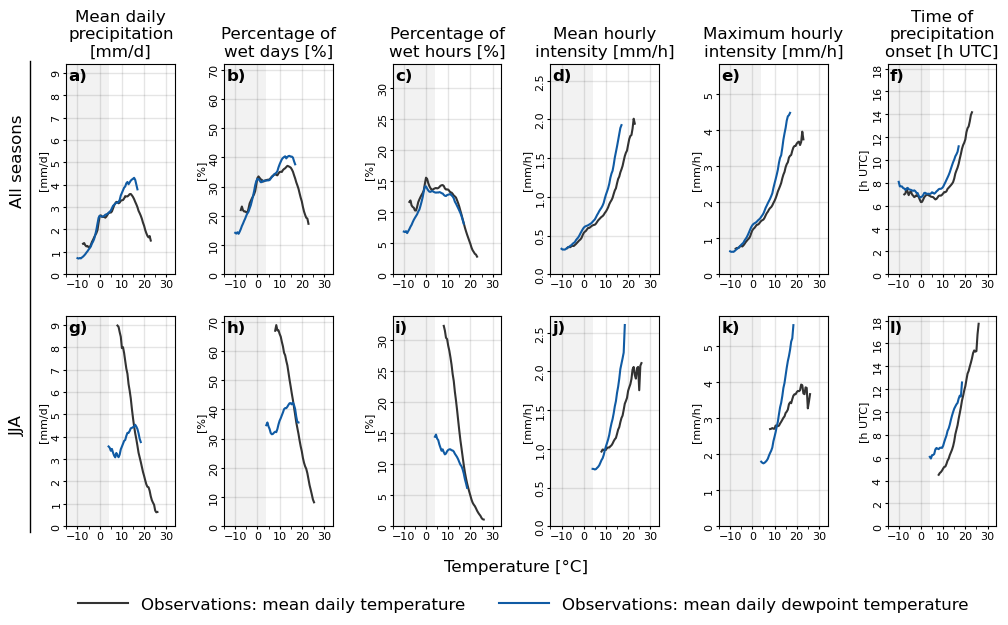

In [10]:
rows = 2

# use gridspec to add whitespace (narrow, empty axes)
gap = 0.45
# second gap bigger: empty space between the daily and the hourly subplots
width_ratios = [1, gap, 1, gap+0.1, 1, gap, 1, gap+0.1, 1, gap+0.1, 1]
gs = mpl.gridspec.GridSpec(2, 11, width_ratios=width_ratios, wspace=0)

# TODO
figname = "TODO"

# initiate figure without axes
fig = plt.figure(figsize=[12, 6])

# create a placeholder array to hold the axes that will be added to the figure according to the gridspec
axes = np.empty((rows, 6),  dtype=object)
# we want 4 rows, 6 columns
for i in range(rows):
    for j in range(6):
        # Skip the empty placeholder axes used to create empty spaces
        gs_col = j * 2

        # If we're in the third row, share y-axis limits with the first row, no sharing otherwise
        if i == 0:
            share_ax = None
        else: 
            share_ax = axes[0, j]

        # add axis to the figure according to gridspec
        ax = fig.add_subplot(gs[i, gs_col], sharey=share_ax)
        # add the created axis to the axes array
        axes[i, j] = ax

# now that axes are created, start plotting
for row_idx, season in enumerate(["allseasons", "JJA"]):
    # 2nd + 3rd column: percentage of wet days and wet hours
    for var_str, color, label in zip(
        ["", "_td"],
        [c1_eval, c1_hist],
        ["Observations: mean daily temperature", "Observations: mean daily dewpoint temperature"],
    ):
        dict_ds_req[f"ds_quantiles_ddmean_{season}{var_str}"]["wet_percentage"].plot(ax=axes[row_idx, 1], ls='-', c=color)
        dict_ds_req[f"ds_quantiles_hdmean_{season}{var_str}"]["wet_percentage"].plot(ax=axes[row_idx, 2], ls='-', c=color)

        # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
        for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
            dict_ds_req[f"ds_daystats_dmean_{season}{var_str}"][v].plot(ax=axes[row_idx, i], ls='-', color=color, label=label)

# Change axes settings: ranges, ticks, labels, etc
for ax in axes.flatten():
    ax.set_xlim(-15, 34)
    ax.set_xlabel("")
    ax.set_ylim(0, None)
    decorate_axis(ax)

# set titles, x- and y-labels of the columns: others are set before
for ax, title in zip(axes[0, :], titles_alldays):
    ax.set_title(title) 

unit_labels = ["[mm/d]", "[%]", "[%]", "[mm/h]", "[mm/h]", "[h UTC]"]
major_ticks_main = [1, 10, 5, 0.5, 1, 2]
labelpad = 2.4
ticklength = 2.25
tickpad = 1.25
for col_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks_main)):
    for row_idx in range(rows):
        # select axis and twin axis
        ax = axes[row_idx, col_idx]
        # add units to each y-axis, set major y-ticks
        ax.set_ylabel(unit, labelpad=labelpad)
        ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))
        ax.tick_params(axis="both", length=ticklength, pad=tickpad)
        ax.tick_params(axis="y", labelrotation=90)
        for label in ax.get_yticklabels():
            label.set_va("center")

# add subplot labels: letters in the upper left corner
for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
    ax.text(0.02, 0.98, f"{letter})", transform=ax.transAxes,
    fontweight="bold", va="top")

# add mean temperature info: vertical line in the corresponding style for all datasets
longdash = (5, (7, 2))

# add text to the first column to add Evaluation/Historical/RCP8.5
x=0.078
fig.text(x, 0.72, "All seasons", rotation=90, fontsize=fontsize, va="center")
fig.text(x, 0.28, "JJA", rotation=90, fontsize=fontsize, va="center")

# add vertical line in the left side of the plot
x = 0.095
fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                color='k', linestyle='-', linewidth=1))

# legend
axes[1, 0].legend(
    # handles=handles_all_datasets,
    bbox_to_anchor=[0, -0.28],
    borderpad=0.2,
    ncol=3,
    handlelength=3,
    frameon=False,
    loc="upper left")

fig.supxlabel("Temperature [°C]", y=0.03)

# Add CC-scaling line (7% increase per 1°C) to intensity columns
x = np.arange(-10, 30, 0.2)
# # TODO come up with good numbers
# for row_idx in range(rows):
#     for y0 in [0.2, 0.4, 0.6, 0.8]:
#         y = y0 * np.power(1.07, x)
#         axes[row_idx, 3].plot(x, y, color=c3_eval, linewidth=0.5, ls=(5, (10, 3)), zorder=0)
#     for y0 in [0.7, 1.0, 1.3, 1.6]:    
#         y = y0 * np.power(1.07, x)
#         axes[row_idx, 4].plot(x, y, color=c3_eval, linewidth=0.5, ls=(5, (10, 3)), zorder=0)

# # save file
# if savefigs:
#     fig.savefig(os.path.join(folder_figures, f"{figname}.pdf"),
#         dpi=200,
#         bbox_inches="tight",
#         format="pdf")

# Figure 3: CC Scaling

## Functions

In [15]:
def plot_CC_figure(
    ds_stations_hd_eval_td, ds_stations_hd_eval,
    lw=2,
    ):
    """
    Produces the Clausius-Clapeyron scaling figure of hourly precipitation versus mean daily temperature

    Args:
        ds_stations_hd_eval, ds_kmscale_hd_eval, ds_driving_hd_eval, ds_kmscale_hd_hist, ds_driving_hd_hist, 
        ds_kmscale_hd_rcp, ds_driving_hd_rcp (xr.Dataset): All input datasets with hourly precipitation 
            quantiles as a function of mean daily temperature
        q_min (float, optional): Lowest quantile to plot, although even lower quantiles might 
            have been calculated. Defaults to 0.9.
        lw (int, optional): Linewidth for the evaluation lines which are supposed to be a bit thicker 
            in the plot than historical/rcp lines. Defaults to 2.

    Returns:
        fig (mpl.Figure): figure object
        axes (np.array): array of axes plotted in the figure
    """

    # initiate figure
    fig, axes=plt.subplots(
        ncols=1, 
        nrows=1,
        dpi=200,
        figsize=[12, 4]
        )
    
    # make a list out of that so I can reuse my other code for multiple subplots: quick'n'dirty
    axes = [axes,]

    # use a thicker linewidth for evaluation to emphasize it
    plot_scaling(ds_stations_hd_eval_td, axes[0], colors=colors_hist, lw=lw)
    plot_scaling(ds_stations_hd_eval, axes[0], colors=colors_eval, lw=lw)

    # temperature bins, used as the x-axis coordinate
    t_bins = ds_stations_hd_eval.temperature_bin

    # All axes: change x-extent, set x-axis ticks, etc
    for ax in axes:
        add_CC_lines(ax, t_bins)
        ax.set_yscale('log')
        ax.set_ylim(0.7, 40)
        ax.set_xlim(-12, 25)
        decorate_axis(ax, axis_grid='x')
        
    # set names of each row + column based on dataset
    axes[0].set_title("Observations: mean daily temperature and mean daily dewpoint temperature")
    return fig, axes

## Plots

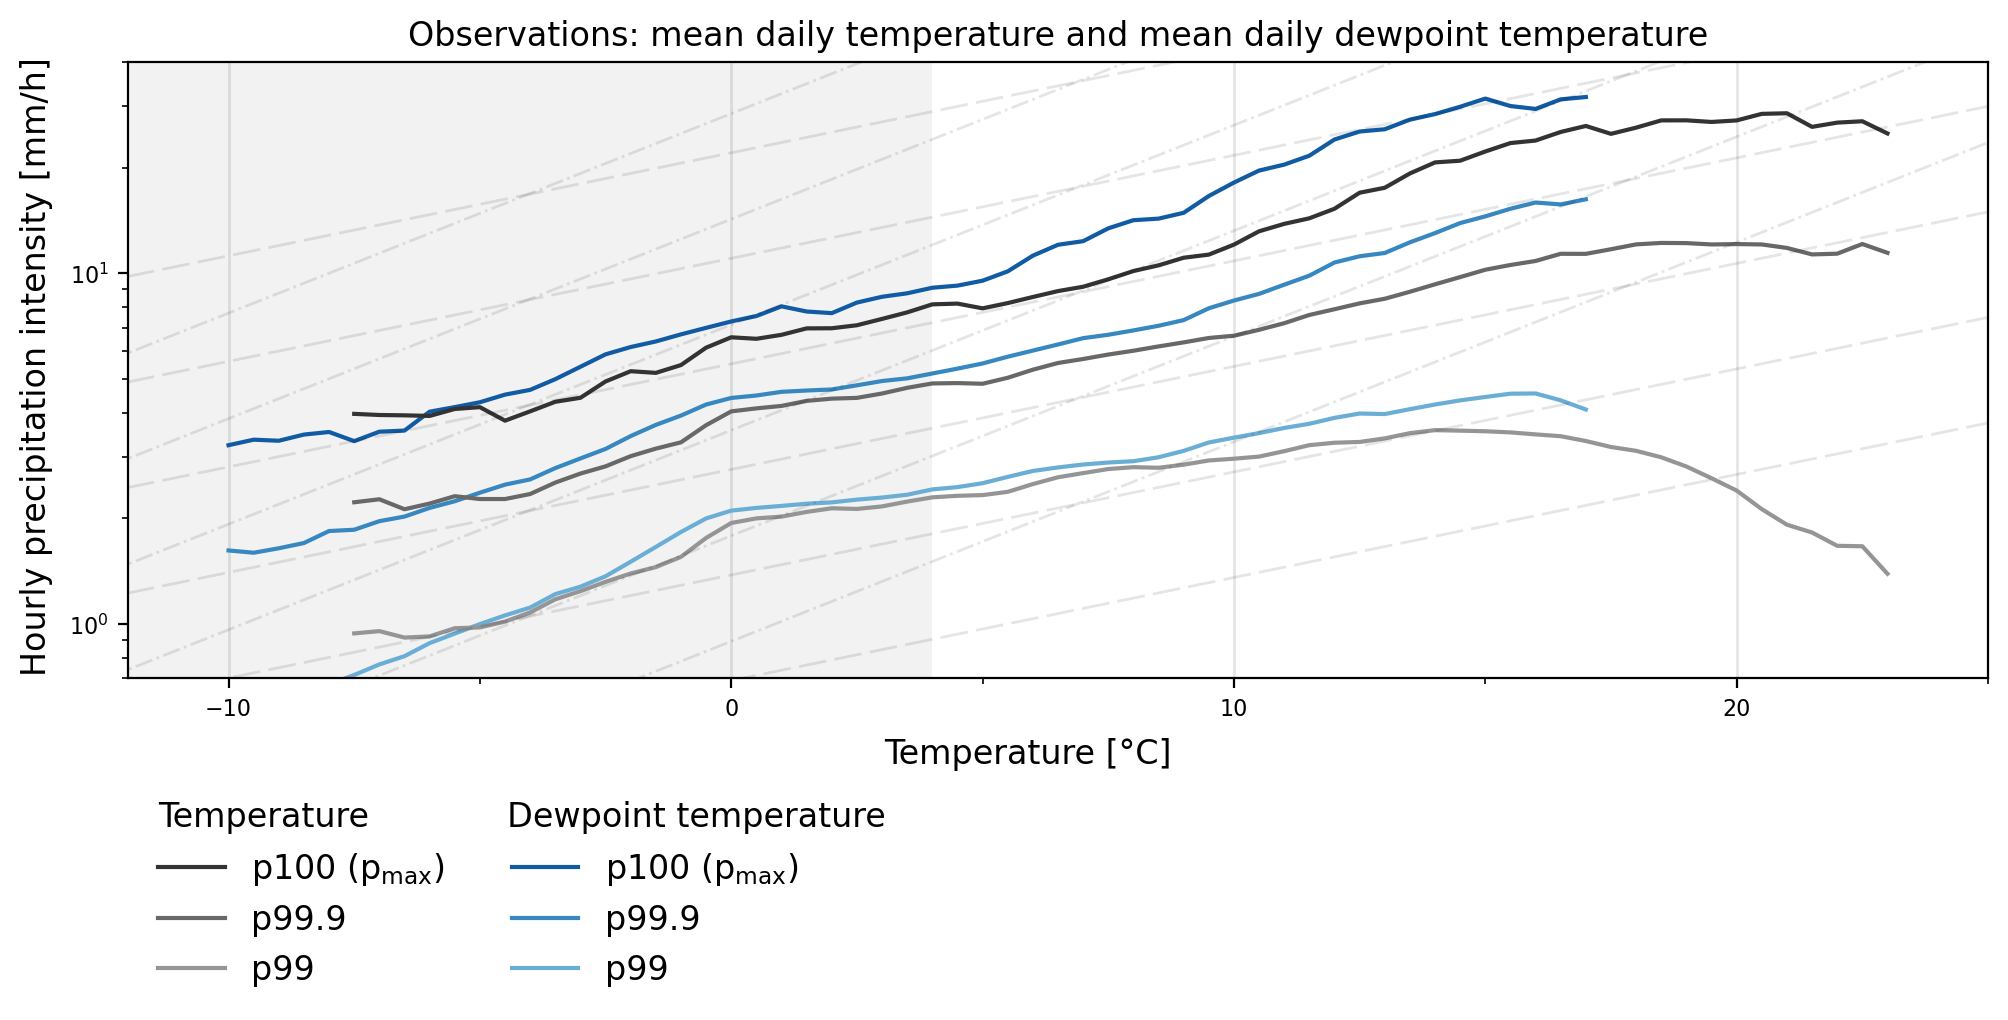

In [16]:
fig, axes = plot_CC_figure(
    dict_ds_req['ds_quantiles_hdmean_allseasons_td'], 
    dict_ds_req['ds_quantiles_hdmean_allseasons'],     
    lw=1.5,
    )

# add shared x and y axis labels
fig.supxlabel("Temperature [°C]", y=-0.005)
fig.supylabel('Hourly precipitation intensity [mm/h]', x=0.08)

# create legend specifically for this figure
handles, labels = axes[0].get_legend_handles_labels()
labels = [lbl.replace('.0', '') + ' ($p_{max}$)' if '100' in lbl else lbl.replace('.0', '') for lbl in labels]
space = " " * 13

legend = axes[0].legend(
    reversed(handles),
    reversed(labels),
    frameon=False,
    bbox_to_anchor=(0, -0.15),
    loc="upper left",
    ncol=2,
    title="Temperature" + space + "Dewpoint temperature",
    alignment = 'left'
)

if savefigs:
    fig.savefig(os.path.join(folder_figures, 'Fig_3.pdf'),
        dpi=200,
        bbox_inches='tight',
        format='pdf')    